# Week 3 Practical: LLM Efficiency Techniques

## Training and Inference Optimization

### Learning Objectives

By the end of this practical session, you will:

1. **Implement LoRA from scratch** (Exercise 1)
   - Understand low-rank adaptation mechanics (W' = W + BA)
   - Apply LoRA to DistilBERT attention layers
   - Understand how to patch a neural networks (torch)
   - Compare to full fine-tuning (~0.5% parameters, similar accuracy)

2. **Implement INT8 Quantization** (Exercise 2)
   - Quantize FFN layers manually using symmetric quantization
   - Analyze accuracy/memory trade-offs (4x compression)
   - Understand post-training quantization techniques

3. **Use HuggingFace PEFT Library** (Exercise 3)
   - Experiment with production PEFT methods (LoRA, Adapters, Prefix Tuning)
   - Compare different parameter-efficient fine-tuning approaches
   - Learn configuration patterns for real-world use

4. **Benchmark Performance** (Exercise 4)
   - Measure memory usage, training time, inference speed
   - Compare all efficiency techniques systematically
   - Understand real-world trade-offs for deployment decisions

## Setup

The next cell imports the necessary modules – just run it, no need to look at
the details!

In [1]:
# Installing required packages

%pip install accelerate==1.12.0
%pip install bertviz==1.4.1
%pip install datasets==4.4.1
%pip install evaluate==0.4.6
%pip install gensim==4.4.0
%pip install matplotlib==3.10.7
%pip install outlines==1.2.9
%pip install pandas==2.3.3
%pip install peft==0.18.0
%pip install scikit-learn==1.7.2
%pip install seaborn==0.13.2
%pip install torch==2.9.1
%pip install transformers==4.57.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 155.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 129.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling sci

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import evaluate
from typing import Tuple, List
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import load_dataset


d:\Sorbonne\M2-MIND\LLM\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_best_device():
    """Returns the best device on this computer"""

    if torch.cuda.is_available():
        device = torch.device("cuda")
        total_memory = torch.cuda.get_device_properties(device).total_memory
        print(f"GPU Memory: {total_memory / 1e9:.1f} GB")
        print(f"GPU Name: {torch.cuda.get_device_name(device)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Found device: {device}")
    return device


device = get_best_device()

GPU Memory: 8.6 GB
GPU Name: NVIDIA GeForce RTX 3070
Found device: cuda


### Load IMDB Dataset

We'll use a subset of IMDB for faster experimentation with efficiency techniques.

In [3]:
print("Loading IMDb dataset...")
dataset = load_dataset("imdb", split="train")
dataset = dataset.map(lambda x: {"labels": x.pop("label")})

# Use a subset (for speed in efficiency experiments)
dataset = dataset.shuffle(seed=42)

# Default dataset configuration (can be modified for faster experimentation)
dataset_size = 10_000
eval_split = 0.05


dataset = dataset.select(range(dataset_size))

# Split into train/val
train_val = dataset.train_test_split(test_size=eval_split, seed=42)
train_dataset = train_val["train"]
eval_dataset = train_val["test"]

print(f"Train: {len(train_dataset)}, Eval: {len(eval_dataset)}")

Loading IMDb dataset...


d:\Sorbonne\M2-MIND\LLM\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\titou\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better pe

Train: 9500, Eval: 500


### Load Pre-trained Sentiment Classifier

Instead of training from scratch, we'll use a pre-trained DistilBERT model
fine-tuned on SST-2 (Stanford Sentiment Treebank). This saves time and provides
a strong baseline for our efficiency experiments.

In [4]:
print("Loading pre-trained sentiment classifier...")
classifier_model_name = "distilbert-base-uncased-finetuned-sst-2-english"
classifier_tokenizer = AutoTokenizer.from_pretrained(classifier_model_name)
classifier_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_model_name
).to(device)

print(f"Model: {classifier_model_name}")
print(f"Parameters: {sum(p.numel() for p in classifier_model.parameters()):,}")

Loading pre-trained sentiment classifier...


d:\Sorbonne\M2-MIND\LLM\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\titou\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling bac

Model: distilbert-base-uncased-finetuned-sst-2-english
Parameters: 66,955,010


### Tokenize Datasets

In [5]:
print("Tokenizing datasets...")


def preprocess_function(examples):
    return classifier_tokenizer(
        examples["text"], truncation=True, max_length=256, padding="max_length"
    )


train_dataset = train_dataset.map(preprocess_function, batched=True)
eval_dataset = eval_dataset.map(preprocess_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
eval_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(
    f"Datasets tokenized with {len(train_dataset[0]['input_ids'])} tokens per example"
)

Tokenizing datasets...


Map: 100%|██████████| 500/500 [00:00<00:00, 4372.99 examples/s]

Datasets tokenized with 256 tokens per example


In [6]:
# Evaluate baseline accuracy on IMDB dataset
print("Evaluating baseline accuracy...")
classifier_model.eval()

# Compute baseline accuracy
accuracy_metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)


training_args = TrainingArguments(
    output_dir="./trained-models/tmp",
    per_device_eval_batch_size=32,
    report_to=None,
)

trainer = Trainer(
    model=classifier_model,
    args=training_args,
    compute_metrics=compute_metrics,
)

prediction_output = trainer.predict(eval_dataset)
classifier_accuracy = compute_metrics(
    (prediction_output.predictions, prediction_output.label_ids)
)["accuracy"]

print(f"Baseline accuracy on IMDB: {classifier_accuracy:.4f}")

Evaluating baseline accuracy...


Baseline accuracy on IMDB: 0.8960


# IMDB statistics and baseline accuracy

In [7]:
print(f"Device: {device}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(eval_dataset)}")
print(f"Model: {classifier_model_name}")
print(f"Baseline accuracy: {classifier_accuracy:.4f}")

Device: cuda
Train samples: 9500
Test samples: 500
Model: distilbert-base-uncased-finetuned-sst-2-english
Baseline accuracy: 0.8960


---
# Exercise 1: Manual LoRA Implementation

## What is LoRA?

**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning method
that freezes the pre-trained model weights and injects trainable low-rank
matrices into each layer.

**Key Idea:** Instead of updating $W \in \mathbb{R}^{d \times d}$ directly, we
learn:

$$W' = W + \Delta W = W + BA$$

where:
- $A \in \mathbb{R}^{d \times r}$ and $B \in \mathbb{R}^{r \times d}$
- $r \ll d$ (rank, typically 4-16)
- $W$ is frozen, only $A$ and $B$ are trained

**Paper:** [LoRA: Low-Rank Adaptation of Large Language
Models](https://arxiv.org/abs/2106.09685) (Hu et al., 2021)

## Step 1.1: Implement LoRALayer

We'll implement a LoRA layer that wraps a standard PyTorch Linear layer.

In [8]:
class LoRALayer(nn.Module):
    """
    LoRA (Low-Rank Adaptation) layer.

    Implements: output = W @ x + (B @ A) @ x * (alpha / r)
    where W is frozen, A and B are trainable.

    Args:
        original_layer: The linear layer to adapt
        r: Rank of adaptation matrices (default: 8)
        alpha: Scaling factor (default: 16, effective scale is alpha/r)
    """

    def __init__(
        self,
        original_layer: nn.Linear,
        r: int = 8,
        alpha: float = 16,
    ):

        # Freeze original layer

        super().__init__()

        self.original_layer = original_layer
        self.r = r
        self.alpha = alpha

        # get the feature shapes
        in_features = original_layer.in_features
        out_features = original_layer.out_features

        # Initialize LoRA matrices A and B
        self.lora_A = nn.Parameter(torch.zeros(r, in_features)) # A being init like this allows immediate grad flow
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))

        # Initialize A with kaiming_uniform (standard init)
        nn.init.kaiming_uniform_(self.lora_A, a=5**0.5)

        # Initialize B with zeros (important: starts as identity)
        nn.init.zeros_(self.lora_B)

        #freeze og params (very important)
        for param in self.original_layer.parameters():
            param.requires_grad = False

        # scaling factor
        self.scaling = self.alpha / self.r


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Implement LoRA forward pass

        # Compute original output
        original_output = self.original_layer(x)

        # Compute LoRA adaptation: B @ A @ x, scaled by alpha/r
        # @ A projects to the low rank
        # and with @ B we get the proper output shape
        lora_output = (x @ self.lora_A.T) @ self.lora_B.T

        # multiply by scaling factor and add to og output
        return original_output + lora_output * self.scaling


    def merge_weights(self):
        """Merge LoRA weights into original layer for deployment."""
        # Optional: Implement weight merging

        delta_w = (self.lora_B @ self.lora_A) * self.scaling

        # the original layers where frozen in the init so to change tgem we need to unfreeze!
        self.original_layer.weight.requires_grad = True
        with torch.no_grad(): # not part of computation graph since its just a param update
          self.original_layer.weight += delta_w
        self.original_layer.weight.requires_grad = False # and freeze again

        # i saw we need to set them to zero? Not sure if this is needed
        # i think we do if we plan on applying lora again after merging
        self.lora_A.data.zero_()
        self.lora_B.data.zero_()


## Step 1.2: Helper Functions

These helper functions will apply LoRA to DistilBERT's attention layers.

In [9]:
def apply_lora_to_distilbert(
    model: nn.Module,
    r: int = 8,
    alpha: float = 16,
    target_modules: List[str] = None,
) -> List[nn.Parameter]:
    """
    Apply LoRA to specific modules in DistilBERT.

    Args:
        model: DistilBERT model
        r: LoRA rank
        alpha: LoRA alpha
        target_modules: Which attention matrices to adapt (q_lin, k_lin, v_lin, out_lin)

    Returns:
        List of LoRA parameters to optimize
    """
    if target_modules is None:
        target_modules = ["q_lin", "v_lin"]

    lora_params = []

    # Iterate through transformer layers
    for i, layer in enumerate(model.distilbert.transformer.layer):
        attention = layer.attention

        for module_name in target_modules:
            if hasattr(attention, module_name):
                original_layer = getattr(attention, module_name)

                # Replace with LoRA layer
                lora_layer = LoRALayer(original_layer, r=r, alpha=alpha)
                setattr(attention, module_name, lora_layer)

                # Collect LoRA parameters
                # HAD TO CHANGE THIS BC THE PREVIOUS DIDNT WORK WITH .A.weight (same for B)
                lora_params.extend([lora_layer.lora_A, lora_layer.lora_B])

                print(f"Applied LoRA to layer {i} -> {module_name}")

    return lora_params


def count_trainable_parameters(model: nn.Module) -> Tuple[int, int]:
    """
    Count trainable vs total parameters.

    Returns:
        (trainable_params, total_params)
    """
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

In [10]:
# Load base model
lora_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_model_name,
    num_labels=2,
).to(device)

# And look at its parameters
lora_model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Step 1.3: Apply LoRA and Train

Now let's apply LoRA to a DistilBERT model and fine-tune it.

In [11]:
# Setup LoRA training

# Freeze ALL model parameters first
for param in lora_model.parameters():
    param.requires_grad = False

# Apply LoRA to attention layers (q_lin and v_lin)
lora_params = apply_lora_to_distilbert(
    model=lora_model,
    r=8,
    alpha=16,
    target_modules=["q_lin", "v_lin"],
)

for p in lora_params:
    p.requires_grad = True

# Count trainable parameters
trainable_params, total_params = count_trainable_parameters(lora_model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable %:          {100 * trainable_params / total_params:.4f}%")


Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 147,456
Total parameters:     67,102,466
Trainable %:          0.2197%


In [ ]:
# Train LoRA model

# Default training configuration (can be reduced for faster experimentation)
num_epochs = 2
logging_steps = 100


print(f"\nTraining LoRA model ({num_epochs} epochs)...")

training_args = TrainingArguments(
    output_dir="./trained-models/lora-distillbert-imdb",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=logging_steps,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=None,
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

# Evaluate
lora_results = trainer.evaluate()
print(f"\nLoRA model accuracy: {lora_results['eval_accuracy']:.4f}")


Training LoRA model (2 epochs)...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.431800,0.262601,0.904000
2,0.325100,0.249441,0.902000



LoRA model accuracy: 0.9020


## Step 1.4: Compare to Baseline

Let's compare LoRA to full fine-tuning.

In [ ]:
# Compare results
print("\n" + "=" * 80)
print("COMPARISON: LoRA vs Full Fine-tuning")
print("=" * 80)

# Full fine-tuning baseline (from distillbert_imdb.py)
baseline_accuracy = classifier_accuracy
print(f"Full fine-tuning: {baseline_accuracy:.4f} accuracy, 66M trainable params")
print(
    f"LoRA (r=8):       {lora_results['eval_accuracy']:.4f} accuracy, "
    f"{trainable_params:,} trainable params"
)
print(f"\nParameter reduction: {100*(1-trainable_params/66e6):.2f}%")
print(f"Accuracy drop: {100*(baseline_accuracy - lora_results['eval_accuracy']):.2f}%")


COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=8):       0.9020 accuracy, 147,456 trainable params

Parameter reduction: 99.78%
Accuracy drop: -0.60%


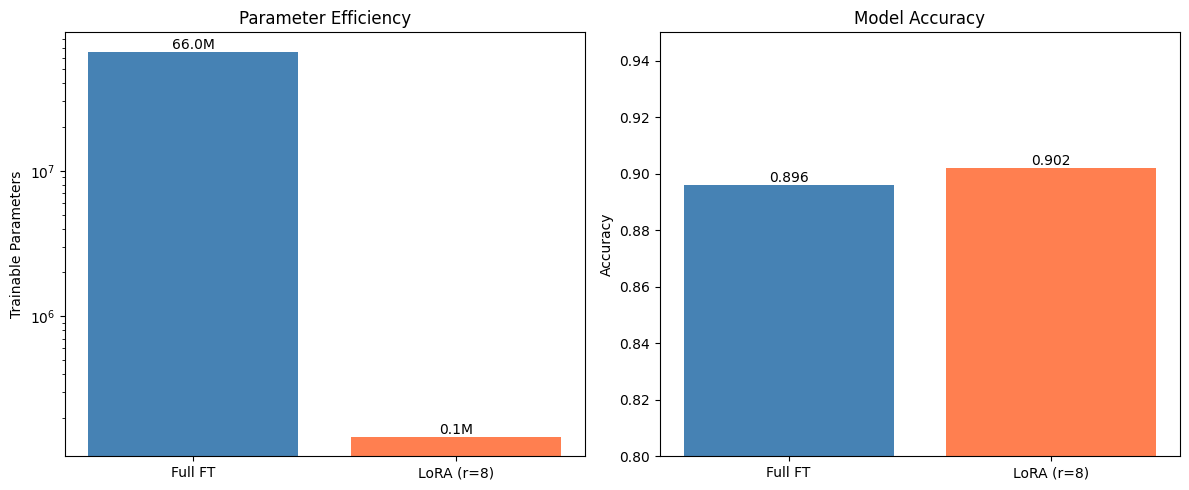

In [ ]:
# visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# compare params
methods = ["Full FT", "LoRA (r=8)"]
params = [66e6, trainable_params]
colors = ["steelblue", "coral"]

ax1.bar(methods, params, color=colors)
ax1.set_ylabel("Trainable Parameters")
ax1.set_title("Parameter Efficiency")
ax1.set_yscale("log")
for i, (method, param) in enumerate(zip(methods, params)):
    ax1.text(i, param, f"{param/1e6:.1f}M", ha="center", va="bottom")

# check accuracies
accuracies = [baseline_accuracy, lora_results["eval_accuracy"]]
ax2.bar(methods, accuracies, color=colors)
ax2.set_ylabel("Accuracy")
ax2.set_title("Model Accuracy")
ax2.set_ylim([0.80, 0.95])
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    ax2.text(i, acc, f"{acc:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Exercise 1 Extension: Experiment with Rank

Try different LoRA ranks and see the trade-off between parameters and accuracy.

In [ ]:
# Experiment with different ranks
ranks = [1, 2, 4, 8, 16, 32]
rank_results = []

for r in ranks:
    print("\n" + "=" * 80)
    print(f"LoRA experiment with rank r={r}")
    print("=" * 80)

    # reload fresh base model
    lora_model = AutoModelForSequenceClassification.from_pretrained(
        classifier_model_name,
        num_labels=2,
    ).to(device)

    # freeze ALL parameters
    for param in lora_model.parameters():
        param.requires_grad = False

    # apply lora (alpha relative to rank)
    lora_params = apply_lora_to_distilbert(
        model=lora_model,
        r=r,
        alpha=2 * r,
        target_modules=["q_lin", "v_lin"],
    )

    for p in lora_params:
        p.requires_grad = True

    # display parameters
    trainable_params, total_params = count_trainable_parameters(lora_model)
    print(f"Trainable parameters: {trainable_params:,}")

    # 1 epoch for speed
    training_args = TrainingArguments(
        output_dir=f"./trained-models/lora-distillbert-imdb-r{r}",
        num_train_epochs=1,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        warmup_steps=50,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",
        report_to=None,
    )

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    acc = eval_results["eval_accuracy"]

    print(f"Eval accuracy (r={r}): {acc:.4f}")

    # reuse previous code to display the results
    print("\n" + "=" * 80)
    print("COMPARISON: LoRA vs Full Fine-tuning")
    print("=" * 80)

    baseline_accuracy = classifier_accuracy
    print(f"Full fine-tuning: {baseline_accuracy:.4f} accuracy, 66M trainable params")
    print(
        f"LoRA (r={r}):       {lora_results['eval_accuracy']:.4f} accuracy, "
        f"{trainable_params:,} trainable params"
    )
    print(f"\nParameter reduction: {100*(1-trainable_params/66e6):.2f}%")
    print(f"Accuracy drop: {100*(baseline_accuracy - lora_results['eval_accuracy']):.2f}%")

    rank_results.append({
        "rank": r,
        "trainable": trainable_params,
        "accuracy": acc,
    })



LoRA experiment with rank r=1
Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 18,432


Epoch,Training Loss,Validation Loss,Accuracy
1,0.514900,0.376294,0.904000


Eval accuracy (r=1): 0.9040

COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=1):       0.9020 accuracy, 18,432 trainable params

Parameter reduction: 99.97%
Accuracy drop: -0.60%

LoRA experiment with rank r=2
Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 36,864


Epoch,Training Loss,Validation Loss,Accuracy
1,0.495500,0.367585,0.898000


Eval accuracy (r=2): 0.8980

COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=2):       0.9020 accuracy, 36,864 trainable params

Parameter reduction: 99.94%
Accuracy drop: -0.60%

LoRA experiment with rank r=4
Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 73,728


...

Eval accuracy (r=8): 0.9020

COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=8):       0.9020 accuracy, 147,456 trainable params

Parameter reduction: 99.78%
Accuracy drop: -0.60%

LoRA experiment with rank r=16
Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 294,912


Epoch,Training Loss,Validation Loss,Accuracy
1,0.391800,0.263195,0.904000


Eval accuracy (r=16): 0.9040

COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=16):       0.9020 accuracy, 294,912 trainable params

Parameter reduction: 99.55%
Accuracy drop: -0.60%

LoRA experiment with rank r=32
Applied LoRA to layer 0 -> q_lin
Applied LoRA to layer 0 -> v_lin
Applied LoRA to layer 1 -> q_lin
Applied LoRA to layer 1 -> v_lin
Applied LoRA to layer 2 -> q_lin
Applied LoRA to layer 2 -> v_lin
Applied LoRA to layer 3 -> q_lin
Applied LoRA to layer 3 -> v_lin
Applied LoRA to layer 4 -> q_lin
Applied LoRA to layer 4 -> v_lin
Applied LoRA to layer 5 -> q_lin
Applied LoRA to layer 5 -> v_lin
Trainable parameters: 589,824


Epoch,Training Loss,Validation Loss,Accuracy
1,0.344800,0.246038,0.904000


Eval accuracy (r=32): 0.9040

COMPARISON: LoRA vs Full Fine-tuning
Full fine-tuning: 0.8960 accuracy, 66M trainable params
LoRA (r=32):       0.9020 accuracy, 589,824 trainable params

Parameter reduction: 99.11%
Accuracy drop: -0.60%


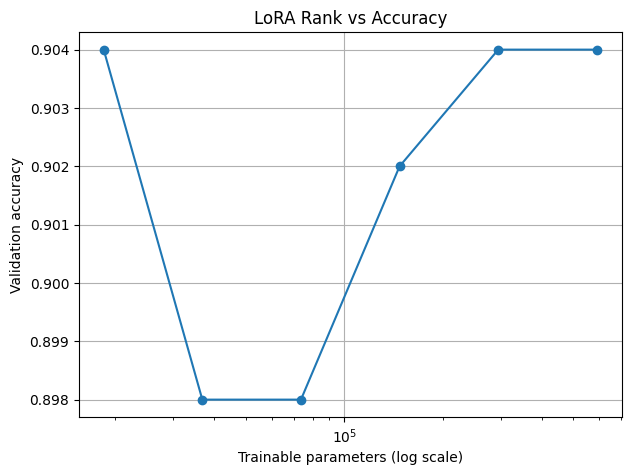

In [ ]:
r_vals = [x["rank"] for x in rank_results]
params = [x["trainable"] for x in rank_results]
accs = [x["accuracy"] for x in rank_results]

plt.figure(figsize=(7, 5))
plt.plot(params, accs, marker="o")
plt.xscale("log")
plt.xlabel("Trainable parameters (log scale)")
plt.ylabel("Validation accuracy")
plt.title("LoRA Rank vs Accuracy")
plt.grid(True)
plt.show()


---
# Exercise 2: Manual INT8 Quantization

## What is Quantization?

**Quantization** converts high-precision floating-point weights (FP32: 32
bits) to low-precision integers (INT8: 8 bits).

**Symmetric Quantization Formula:**

$$\text{quantized} =
\text{round}\left(\frac{\text{original}}{\text{scale}}\right)$$

where:

$$\text{scale} = \frac{\max(|\text{original}|)}{127}$$

**Dequantization:**

$$\text{dequantized} = \text{quantized} \times \text{scale}$$

## Step 2.1: Implement Quantization Functions

In [12]:
def quantize_tensor(
    tensor: torch.Tensor,
    bits: int = 8,
) -> Tuple[torch.Tensor, float]:
    """
    Quantize tensor to INT8 using symmetric quantization.

    Args:
        tensor: FP32 tensor to quantize
        bits: Number of bits (default: 8)

    Returns:
        quantized: INT8 tensor
        scale: Scale factor for dequantization
    """
    # Implement symmetric INT8 quantization

    # Compute scale factor
    qmax = 2 ** (bits - 1) - 1  # 127 for INT8
    max_val = tensor.abs().max()
    scale = max_val / qmax if max_val != 0 else 1.0

    # Quantize: divide by scale, round, clamp to INT8 range
    quantized = torch.round(tensor / scale)
    quantized = torch.clamp(quantized, -qmax, qmax)
    quantized = quantized.to(torch.int8)

    return quantized, scale



def dequantize_tensor(
    quantized: torch.Tensor,
    scale: float,
) -> torch.Tensor:
    """
    Dequantize INT8 tensor back to FP32.

    Args:
        quantized: INT8 tensor
        scale: Scale factor from quantization

    Returns:
        dequantized: FP32 tensor
    """
    # Implement dequantization

    # Convert to float and multiply by scale
    dequantized = quantized.float() * scale

    return dequantized


## Step 2.2: Test Quantization

Let's test our quantization on a sample tensor.

In [13]:
# Test quantization
test_tensor = torch.randn(1000, 768)
print(f"Original tensor: shape={test_tensor.shape}, dtype={test_tensor.dtype}")
print(f"Original range: [{test_tensor.min():.4f}, {test_tensor.max():.4f}]")
print(f"Original memory: {test_tensor.nbytes / 1e6:.2f} MB")

# Quantize
quantized, scale = quantize_tensor(test_tensor)
print(f"\nQuantized tensor: shape={quantized.shape}, dtype={quantized.dtype}")
print(f"Quantized range: [{quantized.min()}, {quantized.max()}]")
print(f"Quantized memory: {quantized.nbytes / 1e6:.2f} MB")
print(f"Scale factor: {scale:.6f}")
print(f"Memory reduction: {test_tensor.nbytes / quantized.nbytes:.1f}x")

# Dequantize
dequantized = dequantize_tensor(quantized, scale)
print(f"\nDequantized tensor: shape={dequantized.shape}, dtype={dequantized.dtype}")
print(f"Dequantized range: [{dequantized.min():.4f}, {dequantized.max():.4f}]")

# Measure error
mse = ((test_tensor - dequantized) ** 2).mean()
print(f"\nReconstruction MSE: {mse:.6f}")
print(f"Relative error: {(mse / test_tensor.var()).sqrt():.4f}")

Original tensor: shape=torch.Size([1000, 768]), dtype=torch.float32
Original range: [-5.0201, 4.8302]
Original memory: 3.07 MB

Quantized tensor: shape=torch.Size([1000, 768]), dtype=torch.int8
Quantized range: [-127, 122]
Quantized memory: 0.77 MB
Scale factor: 0.039529
Memory reduction: 4.0x

Dequantized tensor: shape=torch.Size([1000, 768]), dtype=torch.float32
Dequantized range: [-5.0201, 4.8225]

Reconstruction MSE: 0.000130
Relative error: 0.0114


## Step 2.3: Visualize Quantization Error

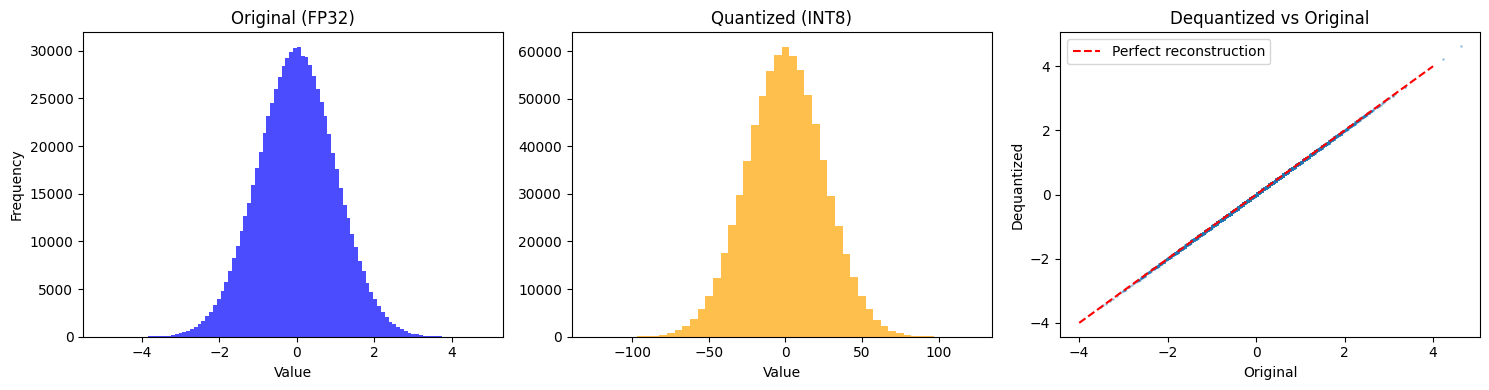

In [11]:
# Visualize weight distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].hist(test_tensor.flatten().numpy(), bins=100, alpha=0.7, color="blue")
axes[0].set_title("Original (FP32)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

# Quantized
axes[1].hist(quantized.flatten().numpy(), bins=50, alpha=0.7, color="orange")
axes[1].set_title("Quantized (INT8)")
axes[1].set_xlabel("Value")

# Dequantized vs Original
axes[2].scatter(
    test_tensor.flatten().numpy()[::100],
    dequantized.flatten().numpy()[::100],
    alpha=0.3,
    s=1,
)
axes[2].plot([-4, 4], [-4, 4], "r--", label="Perfect reconstruction")
axes[2].set_title("Dequantized vs Original")
axes[2].set_xlabel("Original")
axes[2].set_ylabel("Dequantized")
axes[2].legend()

plt.tight_layout()
plt.show()

## Step 2.4: Implement Quantized Linear Layer

In [14]:
class QuantizedLinear(nn.Module):
    """
    Quantized linear layer for FFN.

    Stores weights in INT8, dequantizes during forward pass.
    This is post-training quantization (PTQ).
    """

    def __init__(self, linear: nn.Linear):
        # Initialize quantized linear layer
        super().__init__()

        self.in_features = linear.in_features
        self.out_features = linear.out_features

        # Quantize weight matrix
        weight_quantized, scale = quantize_tensor(linear.weight.data)

        # Store as buffer (not parameter - don't train)
        self.register_buffer("weight_quantized", weight_quantized)
        self.register_buffer("weight_scale", torch.tensor(scale))

        # Keep bias as float (small, not worth quantizing)
        if linear.bias is not None:
            self.register_buffer("bias", linear.bias.data.clone())
        else:
            self.bias = None




    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Forward pass with dequantization

        # Dequantize weights on the fly
        weight = self.weight_quantized.float() * self.weight_scale

        # Apply linear transformation
        return F.linear(x, weight, self.bias)


    def get_memory_size(self) -> float:
        """Returns memory size in MB."""
        size = self.weight_quantized.nbytes  # INT8 weights
        if self.bias is not None:
            size += self.bias.nbytes
        return size / 1e6

## Step 2.5: Quantize DistilBERT FFN Layers

In [15]:
def quantize_distilbert_ffn(model: nn.Module) -> nn.Module:
    """
    Quantize all FFN layers (lin1, lin2) in DistilBERT.

    Args:
        model: DistilBERT model

    Returns:
        Model with quantized FFN layers
    """
    for i, layer in enumerate(model.distilbert.transformer.layer):
        ffn = layer.ffn

        # Quantize lin1 (768 -> 3072)
        ffn.lin1 = QuantizedLinear(ffn.lin1)

        # Quantize lin2 (3072 -> 768)
        ffn.lin2 = QuantizedLinear(ffn.lin2)

        print(f"Quantized layer {i} FFN (lin1, lin2)")

    return model


def measure_model_size(model: nn.Module) -> float:
    """
    Measure model size in MB.

    Returns:
        Size in MB
    """
    size = 0
    for param in model.parameters():
        size += param.numel() * param.element_size()
    for buffer in model.buffers():
        size += buffer.numel() * buffer.element_size()
    return size / 1e6

In [16]:
# get a new model
base_model = AutoModelForSequenceClassification.from_pretrained(
        classifier_model_name,
        num_labels=2,
    ).to(device)

baseline_accuracy = classifier_accuracy

# Measure original size
original_size = measure_model_size(base_model)

# Quantize FFN layers
quantized_model = quantize_distilbert_ffn(base_model)

# Measure quantized size
quantized_size = measure_model_size(quantized_model)

print(f"Original model size:  {original_size:.2f} MB")
print(f"Quantized model size: {quantized_size:.2f} MB")
print(f"Size reduction:      {100 * (1 - quantized_size / original_size):.2f}%")


# Evaluate accuracy
quantized_model.eval()
from transformers import Trainer

trainer_quant = Trainer(
    model=quantized_model,
    args=TrainingArguments(output_dir="./trained-models/tmp", report_to=None),
    compute_metrics=compute_metrics,
)
prediction_output = trainer_quant.predict(eval_dataset)
quantized_accuracy = compute_metrics(
    (prediction_output.predictions, prediction_output.label_ids)
)["accuracy"]

print(f"\nOriginal accuracy: {baseline_accuracy:.4f}")
print(f"Quantized accuracy: {quantized_accuracy:.4f}")
print(f"Accuracy drop: {100*(baseline_accuracy - quantized_accuracy):.2f}%")

C:\Users\titou\AppData\Local\Temp\ipykernel_22600\1727849573.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("weight_scale", torch.tensor(scale))


Quantized layer 0 FFN (lin1, lin2)
Quantized layer 1 FFN (lin1, lin2)
Quantized layer 2 FFN (lin1, lin2)
Quantized layer 3 FFN (lin1, lin2)
Quantized layer 4 FFN (lin1, lin2)
Quantized layer 5 FFN (lin1, lin2)
Original model size:  267.82 MB
Quantized model size: 182.89 MB
Size reduction:      31.71%



Original accuracy: 0.8960
Quantized accuracy: 0.9000
Accuracy drop: -0.40%


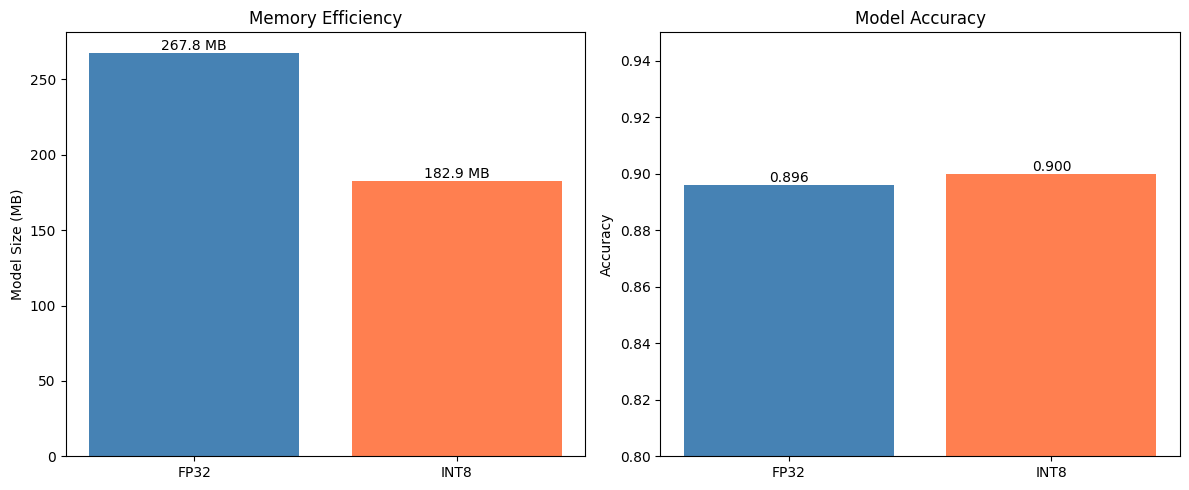

In [18]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Memory comparison
methods = ["FP32", "INT8"]
sizes = [original_size, quantized_size]
colors = ["steelblue", "coral"]

ax1.bar(methods, sizes, color=colors)
ax1.set_ylabel("Model Size (MB)")
ax1.set_title("Memory Efficiency")
for i, (method, size) in enumerate(zip(methods, sizes)):
    ax1.text(i, size, f"{size:.1f} MB", ha="center", va="bottom")

# Accuracy comparison
accuracies = [baseline_accuracy, quantized_accuracy]
ax2.bar(methods, accuracies, color=colors)
ax2.set_ylabel("Accuracy")
ax2.set_title("Model Accuracy")
ax2.set_ylim([0.80, 0.95])
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    ax2.text(i, acc, f"{acc:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

---
# Exercise 3: HuggingFace PEFT Library

## Introduction to PEFT

The [PEFT (Parameter-Efficient Fine-Tuning) library by
HuggingFace](https://huggingface.co/blog/peft) provides production-ready
implementations of various efficiency methods:

- **LoRA**: Low-rank adaptation (we implemented this in Exercise 1)
- **Adapters**: Bottleneck layers inserted after transformer blocks
- **Prefix Tuning**: Learnable "virtual tokens" prepended to input
- **IA3**: Learned element-wise rescaling of activations

**Benefits:**
- Battle-tested implementations
- Easy to switch between methods
- Modular: One base model, many task-specific adapters
- Active development and community support

In [17]:
from peft import (
    LoraConfig,
    IA3Config,
    get_peft_model,
    PeftModel,
)

## Step 3.2: LoRA with PEFT

In [18]:
# Configure LoRA using PEFT library

# Configure LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS",
)

base_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_model_name,
    num_labels=2,
).to(device)

# Apply LoRA
peft_lora_model = get_peft_model(base_model, lora_config)


In [25]:
num_epochs = 2
logging_steps = 100

# Train PEFT LoRA model
training_args_peft = TrainingArguments(
    output_dir="./trained-models/peft-lora-distillbert-imdb",
    num_train_epochs=num_epochs,  # Use same config as manual LoRA
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=logging_steps,  # Use same config as manual LoRA
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=None,
)

trainer_peft = Trainer(
    model=peft_lora_model,
    args=training_args_peft,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer_peft.train()
peft_lora_results = trainer_peft.evaluate()
print(f"PEFT LoRA accuracy: {peft_lora_results['eval_accuracy']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.313000,0.246443,0.916000
2,0.308700,0.243205,0.912000


PEFT LoRA accuracy: 0.9120


## Step 3.3: Compare Other PEFT Methods

In [29]:
# Compare different PEFT methods

results = {}

peft_configs = {
    'IA3': IA3Config(
    target_modules=["q_lin", "v_lin", "out_lin", "lin1", "lin2"],
    feedforward_modules=["lin1", "lin2"],
    task_type="SEQ_CLS",
    ),
    "LoRA": LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_lin", "v_lin"],
        lora_dropout=0.1,
        bias="none",
        task_type="SEQ_CLS",
    ),
}

for name, peft_config in peft_configs.items():
    print(f"\nRunning PEFT method: {name}")

    # Load fresh base model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        classifier_model_name,
        num_labels=2,
    ).to(device)

    # Apply PEFT
    peft_model = get_peft_model(base_model, peft_config)

    # Train
    training_args = TrainingArguments(
        output_dir=f"./trained-models/peft-{name.lower()}",
        num_train_epochs=1,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",
        report_to=None,
    )

    trainer = Trainer(
        model=peft_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # Evaluate
    eval_results = trainer.evaluate()
    results[name] = eval_results["eval_accuracy"]

# Display results
print("\n" + "=" * 80)
print("PEFT METHOD COMPARISON")
print("=" * 80)
for name, acc in results.items():
    print(f"{name:10s}: {acc:.4f} accuracy")



Running PEFT method: IA3


Epoch,Training Loss,Validation Loss,Accuracy
1,0.312900,0.252456,0.904000



Running PEFT method: LoRA


Epoch,Training Loss,Validation Loss,Accuracy
1,0.312700,0.250061,0.906000



PEFT METHOD COMPARISON
IA3       : 0.9040 accuracy
LoRA      : 0.9060 accuracy


In [ ]:
trainable_params = {}
for name, peft_config in peft_configs.items():
    base_model = AutoModelForSequenceClassification.from_pretrained(
        classifier_model_name,
        num_labels=2,
    ).to(device)
    peft_model = get_peft_model(base_model, peft_config)

    # Count trainable parameters
    trainable_params[name] = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)

df_peft = pd.DataFrame({
    "Method": list(results.keys()),
    "Trainable Params": [trainable_params[m] for m in results.keys()],
    "Accuracy": [results[m] for m in results.keys()],
})

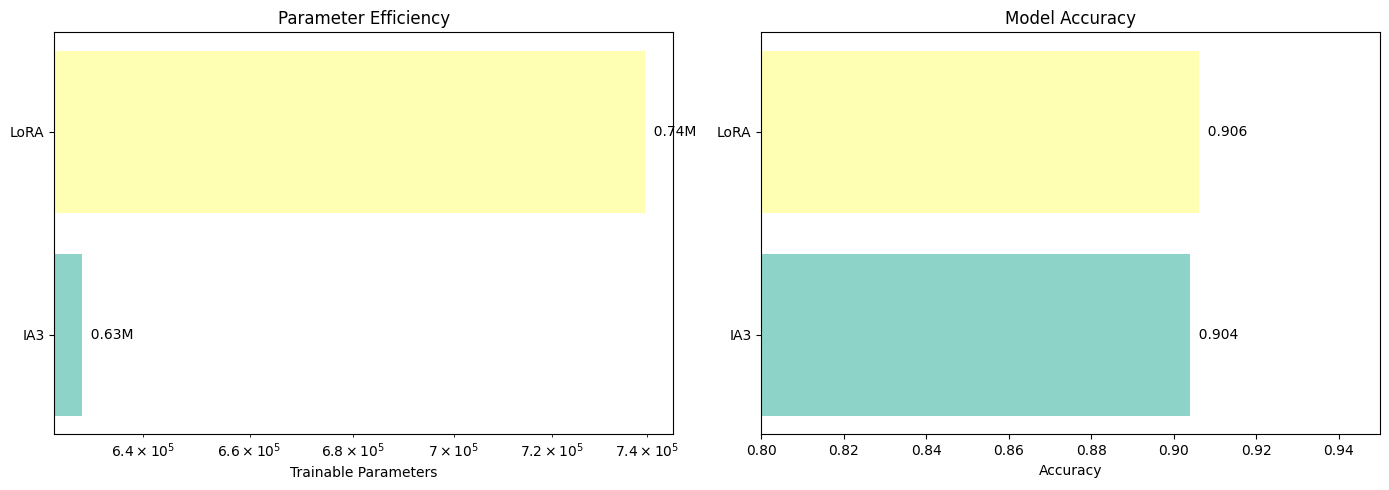

In [31]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trainable parameters
methods = df_peft["Method"].tolist()
params = df_peft["Trainable Params"].tolist()
colors = plt.cm.Set3(range(len(methods)))

ax1.barh(methods, params, color=colors)
ax1.set_xlabel("Trainable Parameters")
ax1.set_title("Parameter Efficiency")
ax1.set_xscale("log")
for i, (method, param) in enumerate(zip(methods, params)):
    ax1.text(param, i, f"  {param/1e6:.2f}M", va="center")

# Accuracy
accuracies = df_peft["Accuracy"].tolist()
ax2.barh(methods, accuracies, color=colors)
ax2.set_xlabel("Accuracy")
ax2.set_title("Model Accuracy")
ax2.set_xlim([0.80, 0.95])
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    ax2.text(acc, i, f"  {acc:.3f}", va="center")

plt.tight_layout()
plt.show()

## Step 3.4: Save and Load PEFT Adapters

In [ ]:
# Save and load PEFT adapter

# Save adapter (only the adapter weights, not the base model)
adapter_save_path = "./peft_lora_adapter"
peft_lora_model.save_pretrained(adapter_save_path)

# load adapter back
# get the new model again (clean fresh one)
base_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_model_name,
    num_labels=2,
).to(device)

loaded_peft_model = PeftModel.from_pretrained(base_model, adapter_save_path)


---
# Project: Performance Benchmarking

## Introduction

Now that we've explored various efficiency techniques, you can
study their effect on:

- **Memory**: Model size (MB)
- **Training Time**: Time per epoch (seconds)
- **Inference Speed**: Samples per second
- **Accuracy**: Test set accuracy

This will help us understand real-world trade-offs and make informed
decisions.

## Memory benchmarking

First things first lets define all the different models that we will test:

- Base model

- Base + LoRA adapter

- Base + IA³ adapter

- Quantized model

- Combinations (QLoRA: LoRA + INT8)

In [19]:
# util fuction to measure the memory
def measure_model_size(model: nn.Module) -> float:
    size = 0
    for param in model.parameters():
        size += param.numel() * param.element_size()
    for buffer in model.buffers():
        size += buffer.numel() * buffer.element_size()
    return size / 1e6


In [20]:
import copy

# we will be reusing those models for other tests most probably
memory_results = {}

memory_results = {}

# Base model
base_model = AutoModelForSequenceClassification.from_pretrained(
    classifier_model_name,
    num_labels=2,
).to(device)
memory_results["Base"] = measure_model_size(base_model)

# LoRA
lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_lin", "v_lin"],
        lora_dropout=0.1,
        bias="none",
        task_type="SEQ_CLS",
    )
peft_lora_model = get_peft_model(copy.deepcopy(base_model), lora_config)
memory_results["LoRA"] = measure_model_size(peft_lora_model)

# IA3
ia3_config = IA3Config(
    target_modules=["q_lin", "v_lin", "out_lin", "lin1", "lin2"],
    feedforward_modules=["lin1", "lin2"],
    task_type="SEQ_CLS",
    )
peft_ia3_model = get_peft_model(copy.deepcopy(base_model), ia3_config)
memory_results["IA3"] = measure_model_size(peft_ia3_model)

# INT8
quantized_model = quantize_distilbert_ffn(copy.deepcopy(base_model))
memory_results["INT8"] = measure_model_size(quantized_model)

# QLoRA
peft_qlora_model = get_peft_model(copy.deepcopy(quantized_model), lora_config)
memory_results["QLoRA"] = measure_model_size(peft_qlora_model)

# model memory
for name, size in memory_results.items():
    print(f"{name:10s}: {size:.2f} MB")


Quantized layer 0 FFN (lin1, lin2)
Quantized layer 1 FFN (lin1, lin2)
Quantized layer 2 FFN (lin1, lin2)
Quantized layer 3 FFN (lin1, lin2)
Quantized layer 4 FFN (lin1, lin2)
Quantized layer 5 FFN (lin1, lin2)
Base      : 267.82 MB
LoRA      : 270.78 MB
IA3       : 270.34 MB
INT8      : 182.89 MB
QLoRA     : 185.85 MB


C:\Users\titou\AppData\Local\Temp\ipykernel_22600\1727849573.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("weight_scale", torch.tensor(scale))


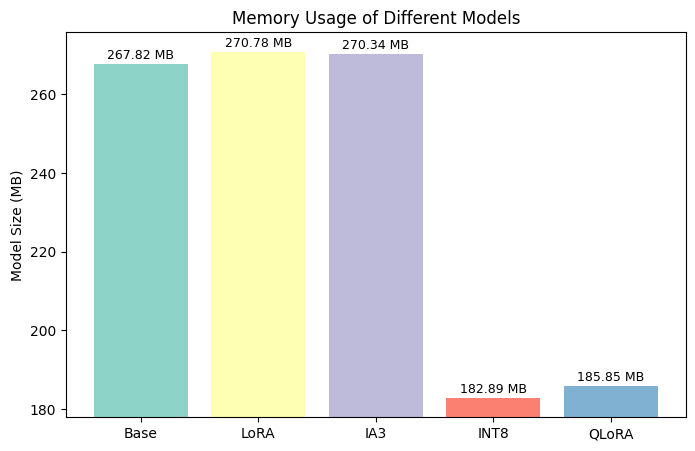

In [ ]:
df_memory = pd.DataFrame({
    "Method": list(memory_results.keys()),
    "Model Size (MB)": [memory_results[m] for m in memory_results.keys()]
})

# bar plot
plt.figure(figsize=(8,5))
bars = plt.bar(df_memory["Method"], df_memory["Model Size (MB)"], color=plt.cm.Set3(range(len(df_memory))))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f} MB", ha='center', va='bottom', fontsize=9)

plt.ylabel("Model Size (MB)")
plt.title("Memory Usage of Different Models")
plt.ylim(min(df_memory["Model Size (MB)"]) - 5, max(df_memory["Model Size (MB)"]) + 5)  # zoom in
plt.show()

## Training Time: Time per epoch (seconds)

Again we will use the 5 previous models and test their training time

In [ ]:
def measure_training_time(model_name, model: nn.Module, train_dataset, per_device_train_batch_size=32, num_train_epochs=1):
    training_args = TrainingArguments(
        output_dir="./tmp",
        per_device_train_batch_size=per_device_train_batch_size,
        num_train_epochs=num_train_epochs,
        logging_steps=1000,
        save_strategy="no",
        report_to=None,
        weight_decay=0,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
    )
    print(f'Testing {model_name} model')
    start_time = time.time()
    trainer.train()
    total_time = time.time() - start_time

    return total_time / num_train_epochs

training_time_results = {}

# Base model (full fine-tuning)
training_time_results["Base"] = measure_training_time('Base', copy.deepcopy(base_model), train_dataset)

# LoRA
training_time_results["LoRA"] = measure_training_time('LoRA', copy.deepcopy(peft_lora_model), train_dataset)

# IA3
training_time_results["IA3"] = measure_training_time('IA3', copy.deepcopy(peft_ia3_model), train_dataset)

# Quantized
training_time_results["Quantized"] = measure_training_time('Quantized', copy.deepcopy(quantized_model), train_dataset)

# QLoRA 
training_time_results["QLoRA"] = measure_training_time('QLoRA', copy.deepcopy(peft_qlora_model), train_dataset)

print("\nTraining Time per Epoch (seconds):")
for name, t in training_time_results.items():
    print(f"{name:10s}: {t:.2f} s")

Testing Base model


Step,Training Loss


Testing LoRA model


Step,Training Loss


Testing IA3 model


...

Testing Quantized model


Step,Training Loss


Testing QLoRA model


Step,Training Loss



Training Time per Epoch (seconds):
Base      : 196.75 s
LoRA      : 150.03 s
IA3       : 155.14 s
Quantized : 161.08 s
QLoRA     : 148.46 s


## Inference Speed

we are going to test how the models perform in test mode

In [ ]:
from torch.utils.data import DataLoader

def measure_inference_speed(model: nn.Module, eval_dataset, batch_size=32):
    # we are going to check the sample processing speed
    model.eval()
    dataloader = DataLoader(eval_dataset, batch_size=batch_size)
    total_samples = 0
    total_time = 0.0

    with torch.no_grad():
        for batch in dataloader:
            # move tensors to device
            inputs = {k: v.to(model.device) for k, v in batch.items() if k in ["input_ids", "attention_mask"]}

            start = time.time()
            _ = model(**inputs)
            end = time.time()

            total_time += (end - start)
            total_samples += inputs["input_ids"].size(0)

    return total_samples / total_time  # samples/sec

# eval on all our models
inference_speed_results = {}
models_to_test = {
    "Base": base_model,
    "LoRA": peft_lora_model,
    "IA3": peft_ia3_model,
    "Quantized": quantized_model,
    "QLoRA": peft_qlora_model
}

for name, model in models_to_test.items():
    speed = measure_inference_speed(model, eval_dataset, batch_size=32)
    inference_speed_results[name] = speed
    print(f"{name:10s}: {speed:.2f} samples/sec")

Base      : 1489.32 samples/sec
LoRA      : 3705.03 samples/sec
IA3       : 3680.59 samples/sec
Quantized : 4810.96 samples/sec
QLoRA     : 3506.95 samples/sec


## Test Set Accuracy

We are now going to check the actual performance of the different models

In [ ]:
accuracy_results = {}

def evaluate_model(model, eval_dataset):
    model.eval()  # eval mode again!
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="./tmp_eval",
            per_device_eval_batch_size=32,
            report_to=None,  # 
        ),
        compute_metrics=compute_metrics,  
    )
    predictions = trainer.predict(eval_dataset)
    acc = compute_metrics((predictions.predictions, predictions.label_ids))["accuracy"]
    return acc

models_to_test = {
    "Base": base_model,
    "LoRA": peft_lora_model,
    "IA3": peft_ia3_model,
    "Quantized": quantized_model,
    "QLoRA": peft_qlora_model
}

for name, model in models_to_test.items():
    acc = evaluate_model(model, eval_dataset)
    accuracy_results[name] = acc
    print(f"{name:10s}: {acc:.4f}")

Base      : 0.896


LoRA      : 0.896


IA3       : 0.896


Quantized : 0.9


QLoRA     : 0.9
